
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E02_sklearn.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Scikit-learn exercises 

---
These are introductory exercises in Machine learning with focus in **scikit-learn** .

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. EDA (*)

In the whole exercise, we will work with the "mpg" dataset from seaborn dataset. Start by loading dataset "mpg" from the ```load_dataset``` method in seaborn module. The goal will be to use linear regression to predict mpg - miles per gallon. 

&nbsp; a) Start by doing some initial EDA such as info(), describe() and figure out what you want to do with the missing values.

&nbsp; b) Use describe only on those columns that are relevant to get statistical information from. 

&nbsp; c) Make some plots on some of the columns that you find interesting.

&nbsp; d) Check if there are any columns you might want to drop. 

<details>

<summary>Answer</summary>

a) I have chosen to drop the rows, but it doesn't neccessary have to be the best method. Maybe some NaNs should be filled somehow?

b)
|      |      mpg |   cylinders |   displacement |   horsepower |   weight |   acceleration |
|:-----|---------:|------------:|---------------:|-------------:|---------:|---------------:|
| mean | 23.4459  |     5.47194 |        194.412 |     104.469  | 2977.58  |       15.5413  |
| std  |  7.80501 |     1.70578 |        104.644 |      38.4912 |  849.403 |        2.75886 |
| min  |  9       |     3       |         68     |      46      | 1613     |        8       |
| 25%  | 17       |     4       |        105     |      75      | 2225.25  |       13.775   |
| 50%  | 22.75    |     4       |        151     |      93.5    | 2803.5   |       15.5     |
| 75%  | 29       |     8       |        275.75  |     126      | 3614.75  |       17.025   |
| max  | 46.6     |     8       |        455     |     230      | 5140     |       24.8     |


c) Here are some example plots

<img src="../assets/EDA_mpg.png" height="400"/>

d) I have chosen to drop the columns origin and name. Think yourself if it is reasonable and feel free to experiment. Also there might be some domain experts in our class, that you can ask. 

</details>

---

In [796]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

mpg_full = sns.load_dataset('mpg')
mpg_full.head()
mpg_full.describe().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.00,398.00,398.00,392.00,398.00,398.00,398.00
mean,23.51,5.45,193.43,104.47,2970.42,15.57,76.01
std,7.82,1.70,104.27,38.49,846.84,2.76,3.70
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00
25%,17.50,4.00,104.25,75.00,2223.75,13.82,73.00
50%,23.00,4.00,148.50,93.50,2803.50,15.50,76.00
75%,29.00,8.00,262.00,126.00,3608.00,17.18,79.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00


In [797]:
mpg_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


Saknas 6 värden i '*horsepower*'. Ska vi droppa dessa rader eller imputera värdena (t.ex. med medelvärde/median)?

In [798]:
mpg_full.dropna(subset=['horsepower'], inplace=True)

In [799]:
mpg_full['origin'].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

In [800]:
n_brands = mpg_full['name'].nunique()
top10_brands = mpg_full['name'].value_counts().sort_values(ascending=False)
print(f'Total number of unique car brands: \033[1m{n_brands}\033[0m \nTop 10 brands: {top10_brands.head(10)}')

Total number of unique car brands: 301 
Top 10 brands: name
amc matador           5
ford pinto            5
toyota corolla        5
chevrolet impala      4
amc hornet            4
ford maverick         4
peugeot 504           4
amc gremlin           4
toyota corona         4
chevrolet chevette    4
Name: count, dtype: int64


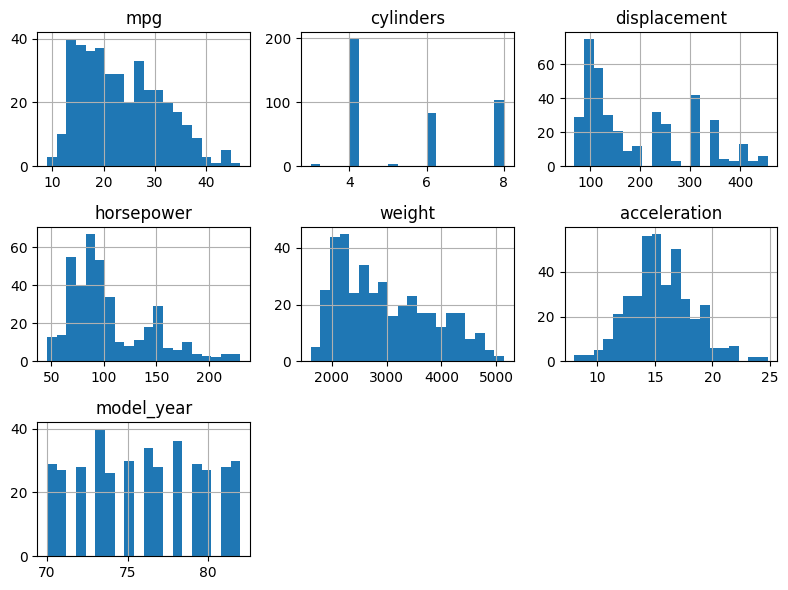

In [801]:
mpg_full.hist(bins=20, figsize=(8,6))
plt.tight_layout()

In [802]:
corr_matrix = mpg_full.drop(columns=['name', 'origin']).corr()
corr_matrix['mpg'].sort_values(ascending=False)

mpg             1.000000
model_year      0.580541
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64

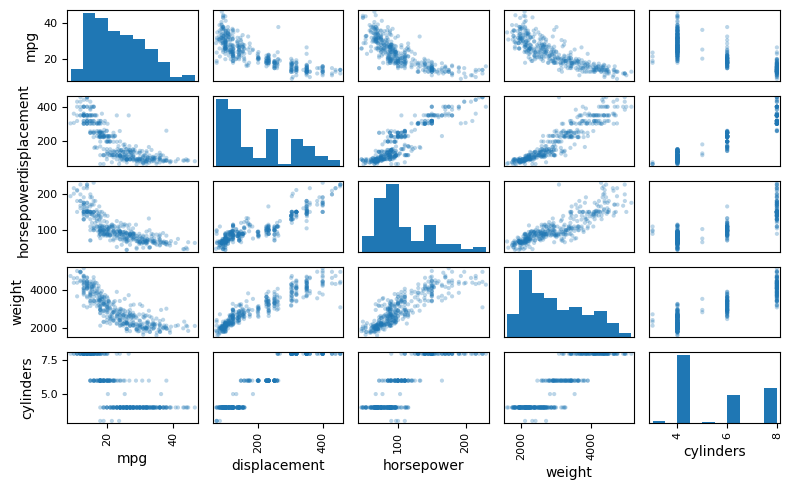

In [803]:
from pandas.plotting import scatter_matrix

attributes = ['mpg', 'displacement', 'horsepower', 'weight', 'cylinders']
scatter_matrix(mpg_full[attributes], figsize=(8,5), alpha=0.3)
plt.tight_layout()
plt.show()


In [805]:
mpg_clean = mpg_full.drop(columns=['name', 'origin'])

mpg_clean.describe().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.00,392.00,392.00,392.00,392.00,392.00,392.00
mean,23.45,5.47,194.41,104.47,2977.58,15.54,75.98
std,7.81,1.71,104.64,38.49,849.40,2.76,3.68
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00
25%,17.00,4.00,105.00,75.00,2225.25,13.78,73.00
50%,22.75,4.00,151.00,93.50,2803.50,15.50,76.00
75%,29.00,8.00,275.75,126.00,3614.75,17.02,79.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00


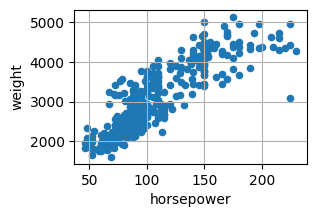

In [813]:
mpg_clean.plot(kind='scatter', x='horsepower', y='weight', figsize=(3,2), grid=True)
plt.show()

---

## 1. Train|test split (*)

We want to predict the "mpg", split up X and y, and perform train|test split using scikit-learn. Choose test_size of 0.2 and random_state 42. Control the shapes of each X_train, X_test, y_train, y_test.  

<details>

<summary>Answer</summary>

Do a manual calculation to check against the shapes after train|test split. 

</details>

---

In [807]:
from sklearn.model_selection import train_test_split

X = mpg_clean.drop(columns=['mpg'])
y = mpg_clean['mpg']

y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y_bins, random_state=42)


In [808]:
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)
print("test/train-ratio:", X_test.shape[0] / X_train.shape[0]) #~80/20 (ca 0.25)

train_bins = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
test_bins  = pd.qcut(y_test,  q=5, labels=False, duplicates='drop')

print("Train bin-fördelning:")
print(train_bins.value_counts(normalize=True).sort_index())

print("Test bin-fördelning:")
print(test_bins.value_counts(normalize=True).sort_index())


X_train: (313, 6) X_test: (79, 6)
y_train: (313,) y_test: (79,)
test/train-ratio: 0.2523961661341853
Train bin-fördelning:
mpg
0    0.220447
1    0.185304
2    0.194888
3    0.198083
4    0.201278
Name: proportion, dtype: float64
Test bin-fördelning:
mpg
0    0.227848
1    0.189873
2    0.189873
3    0.189873
4    0.202532
Name: proportion, dtype: float64


## 2. Function for evaluation (*)

Create a function for training a regression model, predicting and computing the metrics MAE, MSE, RMSE. It should take in parameters of X_train, X_test, y_train, y_test, model. Now create a linear regression model using scikit-learns ```LinearRegression()``` (OLS normal equation with SVD) and call your function to get metrics. 

<details>

<summary>Answer</summary>

MAE 2.50

MSE 10.50

RMSE 3.24

</details>

In [809]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def evaluate_regression_model(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return pd.DataFrame([{"MAE":round(mae, 4), 
                          "MSE":round(mse, 4), 
                          "RMSE":round(rmse, 4), 
                          "R2":round(r2, 4)
                          }])


---
## 3. Compare models (*)

Create the following models 
- Linear regression (SVD)
- Linear regression (SVD) with scaled data (feature standardization)
- Polynomial linear regression with degree 1
- Polynomial linear regression with degree 2
- Polynomial linear regression with degree 3

Make a DataFrame with evaluation metrics and model. Which model performed overall best?

<details>

<summary>Answer</summary>

|      |   Linear regr. SVD |   Linear regr. SVD scaled |   Linear regr. SGD |   Polynom. regr. deg 1 |   Polynom. regr. deg 2 |   Polynom. regr. deg 3 |
|:-----|-------------------:|--------------------------:|-------------------:|-----------------------:|-----------------------:|-----------------------:|
| mae  |            2.50386 |                   2.50386 |            2.53515 |                2.50386 |                1.98048 |                2.11788 |
| mse  |           10.5024  |                  10.5024  |           10.8908  |               10.5024  |                7.41986 |                9.27353 |
| rmse |            3.24074 |                   3.24074 |            3.30012 |                3.24074 |                2.72394 |                3.04525 |

</details>

---

### Linear regr. SVD scaled

In [810]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

svd_pipeline = Pipeline([
    ('model', LinearRegression())
])

svd_scaled_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

sgd_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDRegressor(
    max_iter=1000, #epochs
    tol=1e-5, #tolerans
    penalty=None,
    n_iter_no_change=100,
    learning_rate='optimal',
    random_state=42))
])

poly1_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=1, include_bias=False)),
    ('scaler', StandardScaler()),
     ('model', LinearRegression())
])

poly2_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
     ('model', LinearRegression())
])

poly3_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
     ('model', LinearRegression())
])

svd_metrics = evaluate_regression_model(X_train, X_test, y_train, y_test, svd_pipeline)
svd_scaled_metrics = evaluate_regression_model(X_train, X_test, y_train, y_test, svd_scaled_pipeline)
sgd_metrics = evaluate_regression_model(X_train, X_test, y_train, y_test, sgd_pipeline)
poly1_metrics = evaluate_regression_model(X_train, X_test, y_train, y_test, poly1_pipeline)
poly2_metrics = evaluate_regression_model(X_train, X_test, y_train, y_test, poly2_pipeline)
poly3_metrics = evaluate_regression_model(X_train, X_test, y_train, y_test, poly3_pipeline)

summary = pd.concat(
    [
        svd_metrics.assign(model="SVD"),
        svd_scaled_metrics.assign(model="SVD_scaled"),
        sgd_metrics.assign(model="SGD"),
        poly1_metrics.assign(model="Poly deg 1"),
        poly2_metrics.assign(model="Poly deg 2"),
        poly3_metrics.assign(model="Poly deg 3"),
    ],
).set_index("model")
summary

,MAE,MSE,RMSE,R2
model,,,,
SVD,2.3924,9.6091,3.0999,0.8427
SVD_scaled,2.3924,9.6091,3.0999,0.8427
SGD,2.4645,10.0626,3.1722,0.8353
Poly deg 1,2.3924,9.6091,3.0999,0.8427
Poly deg 2,1.9238,8.8581,2.9763,0.8550
Poly deg 3,2.9600,24.3176,4.9313,0.6019



## 4. Further explorations (**)

Feel free to further explore the dataset, for example you could choose to 
- drop different columns
- find out feature importance in polynomial models
- fine tune further for a specific model by exploring hyperparameters (check documentation which type of parameters that can be changed)

In [818]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge_poly3 = Pipeline([
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
     ('scaler', StandardScaler()),
     ('model', Ridge())
])

param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}
grid= GridSearchCV(ridge_poly3, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

best_poly3 = grid.best_estimator_
poly3_ridge_metrics = evaluate_regression_model(X_train, X_test, y_train, y_test, best_poly3)
poly3_ridge_metrics

,MAE,MSE,RMSE,R2
0,1.9436,8.5927,2.9313,0.8593


---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---